# English → Hindi Machine Translation: Does More (Synthetic) Data Help?

**Experiment**: Compare fine-tuning `Helsinki-NLP/opus-mt-en-hi` on 3000 parallel pairs (baseline having 1000 duplicated sentences from data itself) vs 3000 pairs (baseline + 1000 LLM-paraphrased English sentences with same Hindi targets).

**Data Split**: 2000 train / 250 validation / 250 test (total 2500 samples, seed=42)

**Workflow**:
1. Load data → split → train baseline
2. Export 1000 samples → paraphrase externally via llm
3. Load paraphrased CSV → build augmented training set → retrain → compare

**Runtime**: Set to `T4 GPU` before running *(Runtime → Change runtime type → T4 GPU)*

## Setup

In [ ]:
!pip install -q transformers datasets evaluate sacrebleu rouge-score sentencepiece

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.3 MB/s eta 0:00:00


In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)
import evaluate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "Helsinki-NLP/opus-mt-en-hi"
MAX_INPUT_LEN = 128
MAX_TARGET_LEN = 128

print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
Device: Tesla T4


## Load & Prepare Data

Sample 2500 pairs from the full IIT-B corpus (seed=42) and split:
- **Train**: 2000 pairs
- **Validation**: 250 pairs (used during training for early stopping)
- **Test**: 250 pairs (held-out for final evaluation)

In [ ]:
from datasets import load_dataset

raw = load_dataset("cfilt/iitb-english-hindi", split="train")
print(f"Full dataset size: {len(raw)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/85.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/500k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

Full dataset size: 1659083


In [ ]:
import pandas as pd

SEED = 42

# Step 1: Sample a larger subset
sampled_large = raw.shuffle(seed=SEED).select(range(20000))

# Step 2: Convert to pandas
df = pd.DataFrame(list(sampled_large["translation"]))

# Step 3: Cleaning (vectorized)

# Remove nulls
df = df.dropna(subset=["en", "hi"])

# Strip whitespace
df["en"] = df["en"].str.strip()
df["hi"] = df["hi"].str.strip()

# Word count filter (> 3 words)
df = df[
    (df["en"].str.split().str.len() > 3) &
    (df["hi"].str.split().str.len() > 3)
]

# Remove numbers and noisy patterns
df = df[
    ~df["en"].str.contains(r"\d|\{.*?\}|\$|%", regex=True) &
    ~df["hi"].str.contains(r"\d|\{.*?\}|\$|%", regex=True)
]

# Step 4: Take final 2500
df_clean = df.sample(n=2500, random_state=SEED).reset_index(drop=True)

# Step 5: Split
train_df = df_clean.iloc[:2000]
val_df   = df_clean.iloc[2000:2250]
test_df  = df_clean.iloc[2250:2500]

train_en, train_hi = train_df["en"].tolist(), train_df["hi"].tolist()
val_en, val_hi     = val_df["en"].tolist(), val_df["hi"].tolist()
test_en, test_hi   = test_df["en"].tolist(), test_df["hi"].tolist()

print(f"Train: {len(train_en)} | Validation: {len(val_en)} | Test: {len(test_en)}")
print("\nSample pair:")
print("EN:", train_en[0])
print("HI:", train_hi[0])

Train: 2000 | Validation: 250 | Test: 250

Sample pair:
EN: Binary search trees is a fundamental data structure used to construct more abstract data structures.
HI: द्विभागी अन्वेषण वृक्ष, एक मौलिक डाटा संरचना है, जो अधिक अमूर्त डाटा संरचनाओं के निर्माण के लिए प्रयोग किया जाता है।


## Export Samples for Paraphrasing

Select 1000 random training samples (fixed seed) and export to CSV.
These will be paraphrased externally using llm

In [ ]:
# Select 1000 random samples from training data for paraphrasing
PARAPHRASE_SEED = 42
PARAPHRASE_COUNT = 1000

rng = np.random.RandomState(PARAPHRASE_SEED)
para_indices = rng.choice(len(train_en), size=PARAPHRASE_COUNT, replace=False)
para_indices.sort()

samples_en = [train_en[i] for i in para_indices]
samples_hi = [train_hi[i] for i in para_indices]

# Save to CSV for external paraphrasing
df_export = pd.DataFrame({"original_en": samples_en, "hi": samples_hi})
df_export.to_csv("samples_to_paraphrase.csv", index=False)
print(f"Exported {len(df_export)} samples to samples_to_paraphrase.csv")
print("\nFirst 3 samples:")
df_export.head(3)

Exported 1000 samples to samples_to_paraphrase.csv

First 3 samples:


,original_en,hi
0,Education 's purpose is to replace an empty mi...,शिक्षा का ध्येय है एक खाली दिमाग को खुले दिमाग...
1,Free space notify threshold,मुक्त स्थान सूचना थ्रेसहोल्ड
2,The distance between clicks necessary to detec...,बहुल क्लिक का पता लगाने के लिए आवश्यक क्लिक के...


In [ ]:
#duplication
train_en+=samples_en
train_hi+=samples_hi

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_hf_dataset(en_list, hi_list):
    return Dataset.from_dict({"en": en_list, "hi": hi_list})

def tokenize(batch):
    model_inputs = tokenizer(
        batch["en"],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding="max_length",
    )
    labels = tokenizer(
        text_target=batch["hi"],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding="max_length",
    )
    # Replace padding token id with -100 so loss ignores them
    label_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in lab]
        for lab in labels["input_ids"]
    ]
    model_inputs["labels"] = label_ids
    return model_inputs

train_dataset_base = make_hf_dataset(train_en, train_hi).map(tokenize, batched=True)
val_dataset         = make_hf_dataset(val_en,   val_hi ).map(tokenize, batched=True)
test_dataset        = make_hf_dataset(test_en,  test_hi).map(tokenize, batched=True)

for ds in [train_dataset_base, val_dataset, test_dataset]:
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenization done.")
print(f"  train : {len(train_dataset_base)}")
print(f"  val   : {len(val_dataset)}")
print(f"  test  : {len(test_dataset)}")

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Tokenization done.
  train : 3000
  val   : 250
  test  : 250


## Baseline Fine-tuning (3000 pairs)

In [ ]:
bleu_metric  = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")
chrf_metric  = evaluate.load("chrf")

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Replace -100 in labels
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,   skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels,  skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    bleu  = bleu_metric.compute(predictions=decoded_preds, references=[[r] for r in decoded_labels])
    rouge = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels)
    chrf  = chrf_metric.compute(predictions=decoded_preds,  references=[[r] for r in decoded_labels])

    return {
        "bleu":    round(bleu["score"], 2),
        "rouge1":  round(rouge["rouge1"], 4),
        "rougeL":  round(rouge["rougeL"], 4),
        "chrf":    round(chrf["score"],  2),
    }

In [ ]:
def get_training_args(output_dir):
    return Seq2SeqTrainingArguments(
        output_dir=output_dir,
        num_train_epochs=10,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=3e-5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="bleu",
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to="none",
    )

def train_and_evaluate(train_ds, val_ds, test_ds, output_dir):
    """Train on train_ds, use val_ds for early stopping, evaluate on test_ds."""
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)
    args = get_training_args(output_dir)

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    # Final evaluation on held-out test set
    test_results = trainer.evaluate(test_ds)
    print("\n📊 Test set results:", test_results)
    return trainer, test_results

In [ ]:
print("=== Training Baseline Model (3000 pairs) ===")
print("  Training on: 3000 pairs | Validation: 250 pairs | Test: 250 pairs\n")
baseline_trainer, baseline_results = train_and_evaluate(
    train_dataset_base, val_dataset, test_dataset, output_dir="./baseline_model"
)

=== Training Baseline Model (3000 pairs) ===
  Training on: 3000 pairs | Validation: 250 pairs | Test: 250 pairs



Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].



📊 Test set results: {'eval_loss': 2.6766862869262695, 'eval_bleu': 30.72, 'eval_rouge1': 0.0232, 'eval_rougeL': 0.0232, 'eval_chrf': 45.37, 'eval_runtime': 22.9725, 'eval_samples_per_second': 10.883, 'eval_steps_per_second': 0.696, 'epoch': 5.0}


## Load Paraphrased Data & Build Augmented Dataset

Load the CSV generated by `generate_paraphrases.py` and combine with the original training data.

In [ ]:
# Load the paraphrased CSV
PARAPHRASE_CSV = "/content/paraphrased_samples.csv"  # adjust path if needed

df_para = pd.read_csv(PARAPHRASE_CSV)
print(f"Loaded {len(df_para)} paraphrased samples from {PARAPHRASE_CSV}")
print("\nSample paraphrases:")
for i in [0, 5, 10]:
    if i < len(df_para):
        print(f"  Paraphrased: {df_para.iloc[i]['paraphrased_en']}")
        print(f"  Hindi      : {df_para.iloc[i]['hi']}")
        print()

Loaded 1000 paraphrased samples from /content/paraphrased_samples.csv

Sample paraphrases:
  Paraphrased: Education 's purpose is to replace an empty mind with an open one.
  Hindi      : शिक्षा का ध्येय है एक खाली दिमाग को खुले दिमाग में बदलना।

  Paraphrased: He urged the Governors to work towards improving the security and welfare of women.
  Hindi      : उन्होंने राज्यपालों से आग्रह किया कि वे महिलाओं की सुरक्षा और कल्याण में सुधार की दिशा में प्रयास करें।

  Paraphrased: Know they (Jews) not that Allah knows what they conceal and what they reveal?
  Hindi      : क्या वे जानते नहीं कि अल्लाह वह सब कुछ जानता है, जो कुछ वे छिपाते और जो कुछ ज़ाहिर करते हैं?



In [ ]:
# Build augmented dataset: original 2000 + 1000 paraphrased
df_para['paraphrased_en'] = df_para['paraphrased_en'].fillna("").astype(str)
df_para["hi"] = df_para["hi"].fillna("").astype(str)
paraphrased_en = df_para['paraphrased_en'].tolist()
paraphrased_hi = df_para["hi"].tolist()

aug_en = train_en[:2000] + paraphrased_en   # 3000 English sentences
aug_hi = train_hi[:2000] + paraphrased_hi   # 3000 Hindi sentences

print(f"Augmented training set size: {len(aug_en)}")

train_dataset_aug = make_hf_dataset(aug_en, aug_hi).map(tokenize, batched=True)
train_dataset_aug.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Augmented training set size: 3000


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

## Augmented Fine-tuning (3000 pairs)

In [ ]:
print("=== Training Augmented Model (3000 pairs) ===")
print("  Training on: 3000 pairs | Validation: 250 pairs | Test: 250 pairs\n")
augmented_trainer, augmented_results = train_and_evaluate(
    train_dataset_aug, val_dataset, test_dataset, output_dir="./augmented_model"
)

=== Training Augmented Model (3000 pairs) ===
  Training on: 3000 pairs | Validation: 250 pairs | Test: 250 pairs



Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Bleu,Rouge1,Rougel,Chrf
1,2.630069,2.953116,23.580000,0.018700,0.018700,40.630000
2,2.203779,2.954591,24.150000,0.018700,0.018700,41.540000
3,1.830381,3.000171,25.900000,0.016000,0.016000,42.410000
4,1.538378,3.047702,25.860000,0.016000,0.016000,41.650000
5,1.388096,3.099583,25.550000,0.016000,0.016000,41.610000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].



📊 Test set results: {'eval_loss': 2.6767547130584717, 'eval_bleu': 30.77, 'eval_rouge1': 0.0232, 'eval_rougeL': 0.0232, 'eval_chrf': 45.36, 'eval_runtime': 22.0271, 'eval_samples_per_second': 11.35, 'eval_steps_per_second': 0.726, 'epoch': 5.0}


## Comparison & Analysis

In [ ]:
# Metrics comparison table (test set results)
metrics = ["eval_bleu", "eval_rouge1", "eval_rougeL", "eval_chrf"]
labels  = ["BLEU",      "ROUGE-1",     "ROUGE-L",     "chrF"]

b_scores = [baseline_results.get(m, 0)  for m in metrics]
a_scores = [augmented_results.get(m, 0) for m in metrics]

df = pd.DataFrame({
    "Metric":           labels,
    "Baseline (3000)":  b_scores,
    "Augmented (3000)": a_scores,
    "Δ (improvement)":  [round(a - b, 4) for a, b in zip(a_scores, b_scores)],
})
print("Test Set Results\n")
print(df.to_string(index=False))

Test Set Results

 Metric  Baseline (3000)  Augmented (3000)  Δ (improvement)
   BLEU          30.7200           30.7700             0.05
ROUGE-1           0.0232            0.0232             0.00
ROUGE-L           0.0232            0.0232             0.00
   chrF          45.3700           45.3600            -0.01


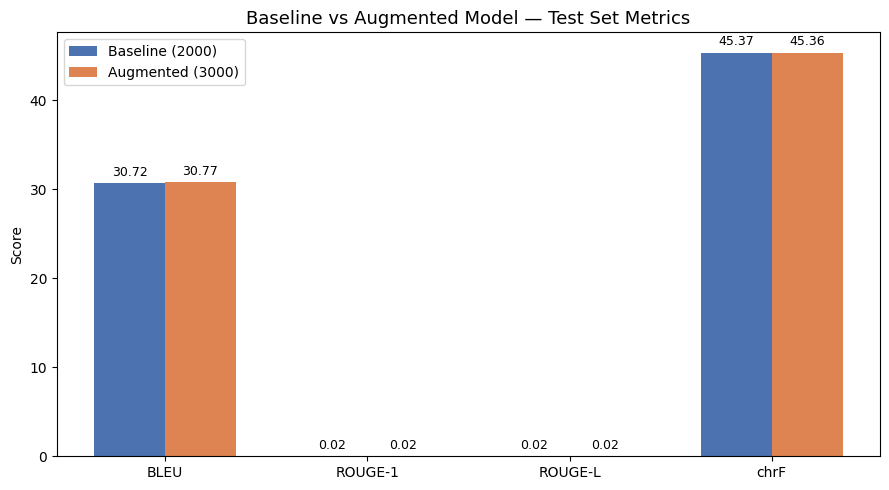

In [ ]:
# Bar chart comparison
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, b_scores, width, label="Baseline (2000)",  color="#4C72B0")
bars2 = ax.bar(x + width/2, a_scores, width, label="Augmented (3000)", color="#DD8452")

ax.set_title("Baseline vs Augmented Model — Test Set Metrics", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Score")
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150)
plt.show()

In [ ]:
# Qualitative comparison on sample test sentences
def translate(model, sentences, batch_size=8):
    model.eval()
    all_outputs = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=MAX_INPUT_LEN).to(model.device)
        with torch.no_grad():
            generated = model.generate(**inputs, max_new_tokens=MAX_TARGET_LEN)
        decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
        all_outputs.extend(decoded)
    return all_outputs

# Pick 15 test sentences for qualitative review
sample_indices = list(range(15))
sample_en = [test_en[i] for i in sample_indices]
sample_hi = [test_hi[i] for i in sample_indices]

baseline_model  = baseline_trainer.model
augmented_model = augmented_trainer.model

base_preds = translate(baseline_model,  sample_en)
aug_preds  = translate(augmented_model, sample_en)

In [ ]:
print(f"{'='*80}")
print("QUALITATIVE TRANSLATION COMPARISON (Test Set)")
print(f"{'='*80}\n")

for i in range(len(sample_en)):
    print(f"[{i+1}] Source (EN)  : {sample_en[i]}")
    print(f"    Reference (HI): {sample_hi[i]}")
    print(f"    Baseline      : {base_preds[i]}")
    print(f"    Augmented     : {aug_preds[i]}")
    print()

QUALITATIVE TRANSLATION COMPARISON (Test Set)

[1] Source (EN)  : O believers, take not the unbelievers as friends instead of the believers; or do you desire to give God over you a clear authority?
    Reference (HI): ऐ ईमान वालों मोमिनीन को छोड़कर काफ़िरों को (अपना) सरपरस्त न बनाओ क्या ये तुम चाहते हो कि ख़ुदा का सरीही इल्ज़ाम अपने सर क़ायम कर लो
    Baseline      : ऐ ईमान लानेवालो! ईमानवालों से हटकर इनकार करनेवालों को अपना मित्र न बनाओ। क्या तुम चाहते हो कि अल्लाह का स्पष्टा तर्क अपने विरुद्ध जुटाओ?
    Augmented     : ऐ ईमान लानेवालो! ईमानवालों से हटकर इनकार करनेवालों को अपना मित्र न बनाओ। क्या तुम चाहते हो कि अल्लाह का स्पष्टा तर्क अपने विरुद्ध जुटाओ?

[2] Source (EN)  : Or that the Ghaib (unseen) is with them, and they write it down?
    Reference (HI): या उनके पास परोक्ष (स्पष्ट) है जिसके आधार पर वे लिए रहे हो?
    Baseline      : या उनके पास परोक्ष (स्पष्ट) है जिसके आधार पर वे लिए रहे हो?
    Augmented     : या उनके पास परोक्ष (स्पष्ट) है जिसके आधार पर वे लिए रहे हो?

[3] Source

## Training Loss Curves

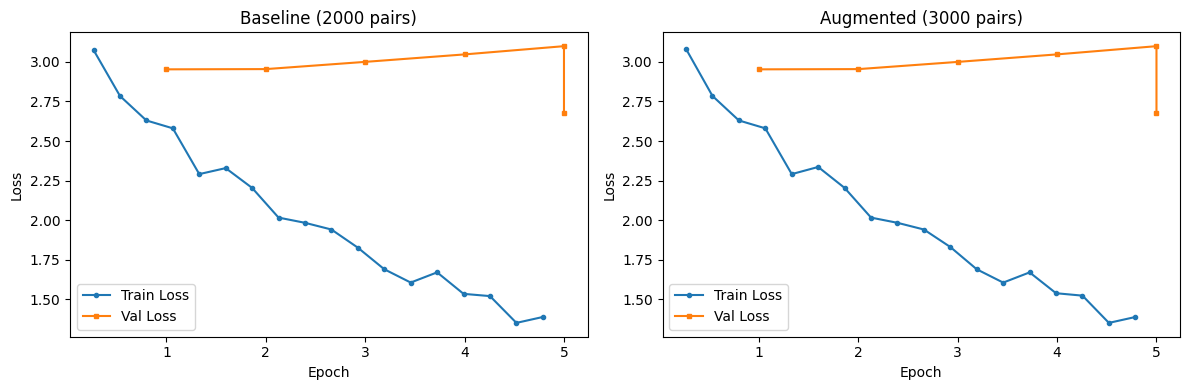

In [ ]:
def extract_loss_history(trainer):
    logs = trainer.state.log_history
    train_loss = [(e["epoch"], e["loss"]) for e in logs if "loss" in e]
    eval_loss  = [(e["epoch"], e["eval_loss"]) for e in logs if "eval_loss" in e]
    return train_loss, eval_loss

b_train_loss, b_eval_loss = extract_loss_history(baseline_trainer)
a_train_loss, a_eval_loss = extract_loss_history(augmented_trainer)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, train_loss, eval_loss, title in [
    (axes[0], b_train_loss, b_eval_loss, "Baseline (2000 pairs)"),
    (axes[1], a_train_loss, a_eval_loss, "Augmented (3000 pairs)"),
]:
    if train_loss:
        ax.plot(*zip(*train_loss), label="Train Loss", marker="o", markersize=3)
    if eval_loss:
        ax.plot(*zip(*eval_loss), label="Val Loss",  marker="s", markersize=3)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

In [ ]:
baseline_model  = baseline_trainer.model
augmented_model = augmented_trainer.model
sample_en=["i am going to school","you wouldn't go to school"]
base_preds = translate(baseline_model,  sample_en)
aug_preds  = translate(augmented_model, sample_en)
for i in range(len(sample_en)):
    print(f"[{i+1}] Source (EN)  : {sample_en[i]}")
    print(f"    Baseline      : {base_preds[i]}")
    print(f"    Augmented     : {aug_preds[i]}")
    print()

[1] Source (EN)  : i am going to school
    Baseline      : मैं स्कूल जा रहा हूँ
    Augmented     : मैं स्कूल जा रहा हूँ

[2] Source (EN)  : you wouldn't go to school
    Baseline      : तुम स्कूल नहीं जाओगे
    Augmented     : तुम स्कूल नहीं जाओगे

